In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms

# transforms
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))]
)

# datasets
trainset = torchvision.datasets.FashionMNIST('./data',
                                            download=True,
                                            train=True,
                                            transform=transform)
testset = torchvision.datasets.FashionMNIST('./data',
                                           download=True,
                                           train=False,
                                           transform=transform)
# dataloaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)

# constant for classes
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5 #反正则
    nping = img.numpy()
    if one_channel:
        plt.imshow(nping, cmap="Greys")
    else:
        plt.imshow(np.transpose(nping, (1, 2, 0)))

In [2]:
# 定义模型
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
net = Net()

In [3]:
# 定义损失和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

### 1 tensorboard安装

In [4]:
# 进入虚拟环境
pip install tensorboard

SyntaxError: invalid syntax (174428774.py, line 2)

### 2 tensorboard的使用

#### 2.1添加图片

In [12]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

In [13]:
images.shape

torch.Size([4, 1, 28, 28])

In [ ]:
# torchvision中make_grid可以把多张图合并成一张图
img_grid = torchvision.utils.make_grid(images)

In [15]:
img_grid.shape

torch.Size([3, 32, 122])

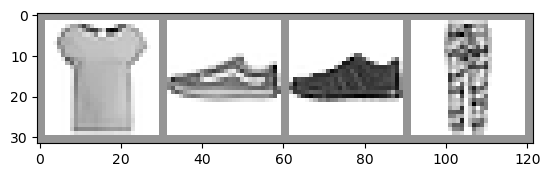

In [16]:
matplotlib_imshow(img_grid, one_channel=True)

In [17]:
from torch.utils.tensorboard import SummaryWriter

In [18]:
writer = SummaryWriter('run/fashion_mnist_experiment_1')

In [19]:
writer.add_image('four_fashion_mnist_images', img_grid)

In [20]:
writer.add_image('four_fashion_mnist_images2', img_grid)

#### 2.2 添加模型结构图

In [21]:
writer.add_graph(net, images)

#### 2.3 添加损失的变化

In [22]:
# writer.add_scalar()
running_loss = 0.0
for epoch in range(1): # loop over the dataset multiple times
    for i, data in enumerate(trainloader, 0):

        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimizer
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 1000 == 999: #every 1000 mini-batches...
            # ... log the running loss
            writer.add_scalar('training loss', 
                              running_loss / 1000,
                             epoch * len(trainloader) + i)
            # ... log a Matplotlib Figure showing the model's predictions on a
            # random mini-batch
            # writer.add_figure('predictions vs. actuals',
            #                  plot_classes_preds(net, inputs, labels),
            #                  global_step=epoch * len(trainloader) + i)
            running_loss = 0.0
print('Finished Training')

Finished Training
